# Fake News Classification - EDA & Baseline

## 1. Load Dataset

In [1]:
import pandas as pd
df = pd.read_csv('../data/WELFake_Dataset.csv', encoding='ISO-8859-1',usecols=['title', 'text', 'label'])


# Show first few rows
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


### Look for any rows missing values and drop them from dataset

In [2]:
df.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [3]:
# Get rid of them
df = df.dropna()

### Check Label Distribution

In [4]:
# Dataset shape
df.shape

(71537, 3)

In [5]:
# See how many 'Fake' & 'Real' entries there are in the datase
df['label'].value_counts()

label
1    36509
0    35028
Name: count, dtype: int64

In [6]:
# Display label distribution as percentages
label_percentages = df['label'].value_counts(normalize=True).rename(index={0: 'Fake', 1: 'Real'}) * 100
label_percentages = label_percentages.round(2)

print(label_percentages)


label
Real    51.04
Fake    48.96
Name: proportion, dtype: float64


## 2. Preprocessing

In [7]:
import re
# Helper function to clean dataset text
def clean_text(text):
    text = str(text).lower()                      # Lowercase
    text = re.sub(r'\d+', '', text)               # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)           # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()      # Remove extra whitespace
    return text

In [8]:
# Call clean_text on dataset
df['clean_text'] = df['text'].apply(clean_text)


In [9]:
# Remove stopwords
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tonyh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
df[['title','clean_text', 'label']].head()

,title,clean_text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,comment expected barack obama members fyf fuky...,1
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,demonstrators gathered last night exercising c...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",dozen politically active pastors came private ...,0
4,SATAN 2: Russia unvelis an image of its terrif...,rs sarmat missile dubbed satan replace ss flie...,1
5,About Time! Christian Group Sues Amazon and SP...,say one time someone sued southern poverty law...,1


### Splitting Data into Train and split

In [11]:
from sklearn.model_selection import train_test_split

# Use the cleaned text and labels
X = df['clean_text']      # Features (cleaned text)
y = df['label']           # Labels (0 = fake, 1 = real)

# Split into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Optional: print sizes
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")


Training samples: 57229
Test samples: 14308


* Clean Text (optional: remove punctuation, lowercase, etc.)
* Tokenize
* Save clean dataset if need

## 3. Baseline model (Logistic Regression)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [13]:
# Convert Text to TF_IDF features
# Limit max features for performance (can tune this later)
vectorizer = TfidfVectorizer(max_features=5000)

# Fit on training data and transform both sets
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [14]:
# Train Logistic Regression
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)


LogisticRegression()

In [15]:
# Make Predictions
y_pred = model.predict(X_test_tfidf)

In [16]:
# Model evaluation
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))


Accuracy: 0.9512859938495947

Classification Report:
              precision    recall  f1-score   support

        Fake       0.96      0.94      0.95      7006
        Real       0.95      0.96      0.95      7302

    accuracy                           0.95     14308
   macro avg       0.95      0.95      0.95     14308
weighted avg       0.95      0.95      0.95     14308



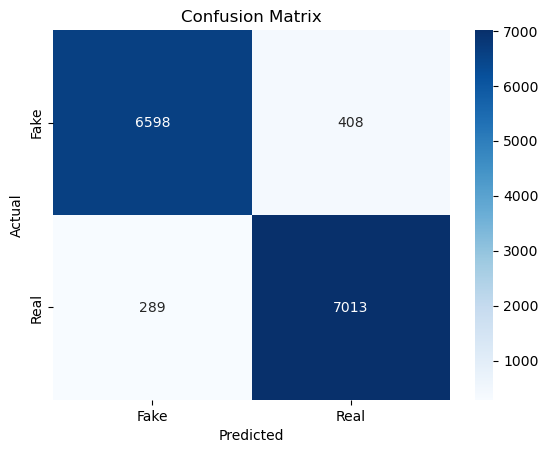

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


- Convert text to TF-IDF vectors
- Train/test/ split
- Fit model
- Evaluate with accuracy, F1-score

## 4. Next Steps

- Plan fine-tuning with Transformers

In [18]:
df.to_csv('../data/cleaned_fake_news.csv', index=False)